### Import Library

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import numpy as np
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load Data

In [2]:
df = pd.read_csv("../dataset/gojek_reviews.csv")
df.head()

,review,score
0,Pokoknya mantap deh naik gojek....keren..,5
1,OK,5
2,"driver tidak bagus, ada yang tdk konfirmasi tr...",2
3,sebenar nya membantu pengiriman tp ada beberap...,3
4,bagus,5


### Cek Identitas Data

In [3]:
print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nTipe data:\n", df.dtypes)

Shape: (70000, 2)

Kolom: ['review', 'score']

Tipe data:
 review      str
score     int64
dtype: object


### Cek Missing Value

In [4]:
df.isna().sum()

review    0
score     0
dtype: int64

### Cek Data Duplikat

In [5]:
df.duplicated(subset=["review"]).sum()

np.int64(21507)

### Drop Data Duplikat

In [6]:
df = df.drop_duplicates(subset=["review"]).copy()

In [7]:
print(len(df))

48493


### Cek Distribusi Skor

In [8]:
print("\nDistribusi score:\n", df["score"].value_counts().sort_index())


Distribusi score:
 score
1    17480
2     2649
3     2438
4     2379
5    23547
Name: count, dtype: int64


### Cek Data (Review) Kosong atau Invalid

In [9]:
df["review_stripped"] = df["review"].astype(str).str.strip()

empty_mask = (
    df["review"].isna()
    | df["review_stripped"].eq("")
    | df["review_stripped"].str.lower().isin(["nan", "none"])
)

df = df.loc[~empty_mask].copy()
df = df.drop(columns=["review_stripped"], errors="ignore")

### Pembersihan Data Teks

In [10]:
def clean_text(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URL
    text = re.sub(r"@\w+|#\w+", " ", text)             # mention/hashtag

    # simbol Unicode (termasuk emoji)
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] not in {"S", "C"})

    # menyisakan huruf-angka-spasi
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # spasi
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

### Normalisasi Slang

In [11]:
kamus_slang = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "gak": "tidak",
    "tdk": "tidak",
    "tak": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "yg": "yang",
    "dr": "dari",
    "dgn": "dengan",
    "tp": "tapi",
    "aja": "saja",
    "krn": "karena",
    "utk": "untuk",
    "jd": "jadi",
    "udh": "sudah",
    "sdh": "sudah",
    "blm": "belum",
    "sm": "sama",
    "klo": "kalau",
    "dl": "dulu",
    "trs": "terus"
}

def normalize_slang(text):
    return ' '.join([kamus_slang.get(word, word) for word in text.split()])

df['clean_review'] = df['clean_review'].apply(normalize_slang)

### Stopword Removal

In [12]:
stop_factory = StopWordRemoverFactory()
stopwords_id = set(stop_factory.get_stop_words())

def remove_stopwords(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_id]
    return " ".join(tokens)

df["clean_review"] = df["clean_review"].apply(remove_stopwords)

### Stemming

In [13]:
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stem_text(text):
    return stemmer.stem(text)

df["clean_review"] = df["clean_review"].apply(stem_text)

In [14]:
before = len(df)

df = df.drop_duplicates(subset=["clean_review"]).copy()
df = df[df["clean_review"].str.strip().str.len() > 0].copy()

after = len(df)

print("Sebelum:", before)
print("Sesudah:", after)
print("Terhapus:", before - after)

Sebelum: 48493
Sesudah: 44337
Terhapus: 4156


### Cek Data Sebelum Labeling

In [15]:
print("Jumlah data akhir:", len(df))
df[["review", "clean_review", "score"]].head(10)

Jumlah data akhir: 44337


,review,clean_review,score
0,Pokoknya mantap deh naik gojek....keren..,pokok mantap deh naik gojek keren,5
2,"driver tidak bagus, ada yang tdk konfirmasi tr...",driver bagus konfirmasi trus tinggal pindah ch...,2
3,sebenar nya membantu pengiriman tp ada beberap...,benar nya bantu kirim beberapa oknum driver te...,3
4,bagus,bagus,5
5,sangat bagus,sangat bagus,5
6,suka dengan aplikasinya.,suka aplikasi,5
7,"driver ranah, sabarrr",driver ranah sabarrr,5
9,drivernya sekarang malesan kalau mendung dikit...,drivernya sekarang malesan kalau mendung dikit...,1
10,"susah cari driver kadang ambil penumpang dulu,...",susah cari driver kadang ambil tumpang dulu to...,2
11,bagus aplikasinya,bagus aplikasi,5


### Cek Distribusi Skor Setelah Cleaning Data

C:\Users\CHRISTIAN\AppData\Local\Temp\ipykernel_24020\270763424.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


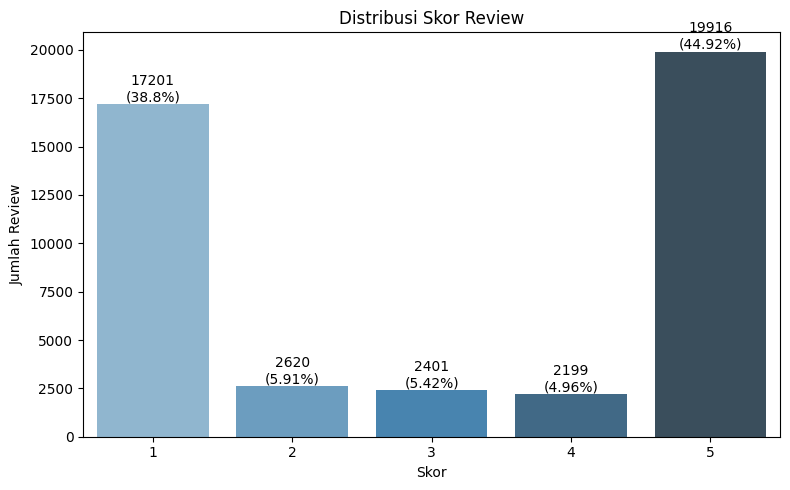

In [16]:
# hitung distribusi
score_counts = df["score"].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(2)

# plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=score_counts.index.astype(str),
    y=score_counts.values,
    palette="Blues_d"
)

# anotasi jumlah + persentase
for i, (count, pct) in enumerate(zip(score_counts.values, score_pct.values)):
    ax.text(i, count, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.title("Distribusi Skor Review")
plt.xlabel("Skor")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.show()

### Labeling Skor

In [17]:
# fungsi untuk labeling
def label_sentiment(score):
    if score <= 2:
        return "negatif"
    elif score == 3:
        return "netral"
    else:
        return "positif"

df["sentiment"] = df["score"].apply(label_sentiment)

# hasil labeling
print("Distribusi label sentimen:")
print(df["sentiment"].value_counts())
df[["clean_review", "score", "sentiment"]].head(10)

Distribusi label sentimen:
sentiment
positif    22115
negatif    19821
netral      2401
Name: count, dtype: int64


,clean_review,score,sentiment
0,pokok mantap deh naik gojek keren,5,positif
2,driver bagus konfirmasi trus tinggal pindah ch...,2,negatif
3,benar nya bantu kirim beberapa oknum driver te...,3,netral
4,bagus,5,positif
5,sangat bagus,5,positif
6,suka aplikasi,5,positif
7,driver ranah sabarrr,5,positif
9,drivernya sekarang malesan kalau mendung dikit...,1,negatif
10,susah cari driver kadang ambil tumpang dulu to...,2,negatif
11,bagus aplikasi,5,positif


### Simpan Dataset Terbaru

In [18]:
df.to_csv("../dataset/gojek_reviews_labeled.csv", index=False)

In [19]:
X = df['clean_review']
y = df['sentiment']

### Skema A (Logistic Regression + TF-IDF word(1,2) + 80/20)

In [20]:
X_train_a_raw, X_test_a_raw, y_train_a, y_test_a = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf_a = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30000,
    sublinear_tf=True
)

X_train_a = tfidf_a.fit_transform(X_train_a_raw)
X_test_a = tfidf_a.transform(X_test_a_raw)

lr_a = LogisticRegression(
    max_iter=3000,
    C=1.0
)

lr_a.fit(X_train_a, y_train_a)
y_pred_a = lr_a.predict(X_test_a)

acc_a = accuracy_score(y_test_a, y_pred_a)
print("Skema A Accuracy:", round(acc_a, 4))
print("\nClassification Report:\n", classification_report(y_test_a, y_pred_a))

Skema A Accuracy: 0.8512

Classification Report:
               precision    recall  f1-score   support

     negatif       0.81      0.91      0.86      3965
      netral       0.43      0.01      0.01       480
     positif       0.90      0.89      0.89      4423

    accuracy                           0.85      8868
   macro avg       0.71      0.60      0.59      8868
weighted avg       0.83      0.85      0.83      8868



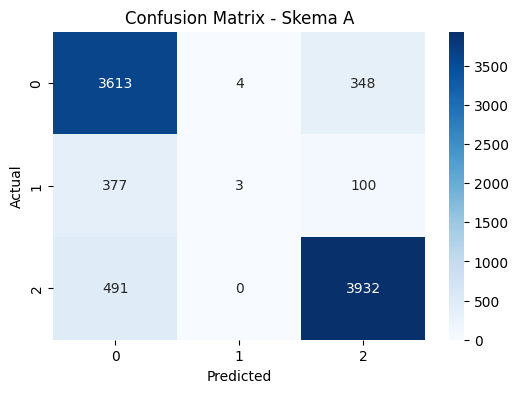

In [21]:
cm_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_a, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Skema A")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Skema B (SGDClassifier + Word2Vec + 80/20)

In [22]:
X_train_b_raw, X_test_b_raw, y_train_b, y_test_b = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# tokenisasi
X_train_tokens_b = [text.split() for text in X_train_b_raw]
X_test_tokens_b = [text.split() for text in X_test_b_raw]

w2v_b = Word2Vec(
    sentences=X_train_tokens_b,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

def sentence_to_vec(tokens, model, vector_size=100):
    valid_vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

X_train_b = np.vstack([sentence_to_vec(tokens, w2v_b, 100) for tokens in X_train_tokens_b])
X_test_b = np.vstack([sentence_to_vec(tokens, w2v_b, 100) for tokens in X_test_tokens_b])

sgd_b = SGDClassifier(
    loss="log_loss",
    alpha=1e-5,
    random_state=42,
    max_iter=5000,
    tol=1e-4
)

sgd_b.fit(X_train_b, y_train_b)
y_pred_b = sgd_b.predict(X_test_b)

acc_b = accuracy_score(y_test_b, y_pred_b)
print("Skema B Accuracy:", round(acc_b, 4))
print("\nClassification Report:\n", classification_report(y_test_b, y_pred_b))

Skema B Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

     negatif       0.77      0.93      0.85      3965
      netral       0.29      0.00      0.01       480
     positif       0.92      0.85      0.88      4423

    accuracy                           0.84      8868
   macro avg       0.66      0.59      0.58      8868
weighted avg       0.82      0.84      0.82      8868



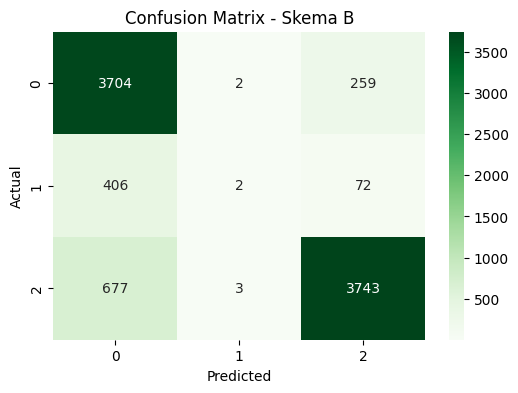

In [23]:
cm_b = confusion_matrix(y_test_b, y_pred_b)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Skema B")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Skema C (LinearSVC + TF-IDF char_wb(3,5) + 75/25)

In [24]:
X_train_c_raw, X_test_c_raw, y_train_c, y_test_c = train_test_split(
    X, y,
    test_size=0.25,   # split 75/25
    random_state=42,
    stratify=y
)

tfidf_c = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_features=50000,
    sublinear_tf=True
)

X_train_c = tfidf_c.fit_transform(X_train_c_raw)
X_test_c = tfidf_c.transform(X_test_c_raw)

svc_c = LinearSVC(
    C=0.5,
    random_state=42
)

svc_c.fit(X_train_c, y_train_c)
y_pred_c = svc_c.predict(X_test_c)

acc_c = accuracy_score(y_test_c, y_pred_c)
print("Skema C Accuracy:", round(acc_c, 4))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Skema C Accuracy: 0.8502

Classification Report:
               precision    recall  f1-score   support

     negatif       0.81      0.91      0.86      4956
      netral       0.20      0.01      0.01       600
     positif       0.89      0.89      0.89      5529

    accuracy                           0.85     11085
   macro avg       0.63      0.60      0.59     11085
weighted avg       0.82      0.85      0.83     11085



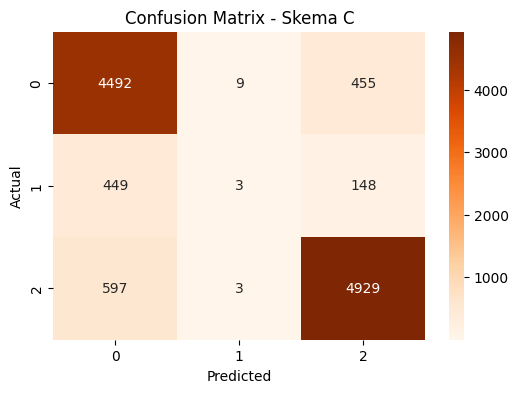

In [25]:
cm_c = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Skema C")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Inference / Testing Sentimen
Bagian ini menggunakan **model yang sudah ditrain sebelumnya** (Skema A: Logistic Regression + TF-IDF)

In [26]:
# Gunakan model + vectorizer yang sudah ditrain pada Skema A
vectorizer_terlatih = tfidf_a
model_terlatih = lr_a

sample_reviews = [
    "Aplikasinya sangat membantu, driver cepat, dan proses pemesanan mudah.",
    "Lumayan, kadang lancar kadang error, tapi masih bisa dipakai.",
    "Aplikasi sering crash, susah login, dan layanan sangat mengecewakan.",
    "Fitur cukup oke namun performa biasa saja.",
    "Pelayanannya buruk dan respon customer service lama sekali."
]

def preprocess_for_inference(text):
    text = clean_text(text)
    text = normalize_slang(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

clean_samples = [preprocess_for_inference(t) for t in sample_reviews]
X_samples = vectorizer_terlatih.transform(clean_samples)
pred_samples = model_terlatih.predict(X_samples)

hasil_inference = pd.DataFrame({
    "review_asli": sample_reviews,
    "review_clean": clean_samples,
    "prediksi_sentimen": pred_samples
})

print("Hasil Inference/Test Sentimen (Model Terlatih):")
display(hasil_inference)

Hasil Inference/Test Sentimen (Model Terlatih):


,review_asli,review_clean,prediksi_sentimen
0,"Aplikasinya sangat membantu, driver cepat, dan...",aplikasi sangat bantu driver cepat proses mesa...,positif
1,"Lumayan, kadang lancar kadang error, tapi masi...",lumayan kadang lancar kadang error pakai,positif
2,"Aplikasi sering crash, susah login, dan layana...",aplikasi sering crash susah login layan sangat...,negatif
3,Fitur cukup oke namun performa biasa saja.,fitur cukup oke performa biasa,positif
4,Pelayanannya buruk dan respon customer service...,layan buruk respon customer service lama sekali,negatif


### Ringkasan dan Kesimpulan Perbandingan Model

Berdasarkan evaluasi tiga skema klasifikasi sentimen, performa model terbaik tetap diperoleh oleh **Skema A (Logistic Regression + TF-IDF word unigram-bigram)** dengan **accuracy 0.8512** dan **F1 Macro 0.59** (dibulatkan).

Skema B (Word2Vec + SGDClassifier) menghasilkan **accuracy 0.8417** dan **F1 Macro 0.58**, sedangkan Skema C (LinearSVC + TF-IDF char_wb 3-5) menghasilkan **accuracy 0.8502** dan **F1 Macro 0.59** (dibulatkan). Secara umum, Skema A dan C masih lebih stabil daripada Skema B versi Word2Vec untuk dataset ini.

Selain itu, kelas **netral** masih menjadi kelas paling sulit diprediksi pada ketiga skema (recall sangat rendah), sehingga peningkatan data/netral balancing dapat dipertimbangkan pada eksperimen berikutnya.

Catatan penting: Skema A dan B diuji dengan split data 80/20, sedangkan Skema C menggunakan split 75/25.